# EDA — Grupo 4 (GDSC2, datos crudos)

Análisis exploratorio sobre el dataset crudo `GDSC2-dataset.csv`.
Objetivos: inspección inicial, estadísticas descriptivas, 3 visualizaciones alineadas a hipótesis, y hallazgos (insights).

# Layer RAW — Ingesta de CSVs 

**Objetivo:** Leer los CSVs originales

**Estructura esperada del repo:**
```
proyecto/
├── Datasets/      ← CSVs originales
└── notebooks/     ← estos notebooks
```


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
sns.set_theme(style='whitegrid')
%matplotlib inline

In [2]:
# Cargar dataset crudo
BASE_DIR = Path().resolve().parent
DATA_PATH = BASE_DIR / 'datasets' / 'GDSC2-dataset.csv'
print('Leyendo:', DATA_PATH)
df = pd.read_csv(DATA_PATH, low_memory=False)
print('\nShape:', df.shape)
display(df.head())
print('\nColumnas:', list(df.columns))
print('\nTipos de datos:\n', df.dtypes.value_counts())

Leyendo: C:\Users\Dell\Desktop\TPO_DBT\datasets\GDSC2-dataset.csv

Shape: (242036, 19)


,DATASET,NLME_RESULT_ID,NLME_CURVE_ID,COSMIC_ID,CELL_LINE_NAME,SANGER_MODEL_ID,TCGA_DESC,DRUG_ID,DRUG_NAME,PUTATIVE_TARGET,PATHWAY_NAME,COMPANY_ID,WEBRELEASE,MIN_CONC,MAX_CONC,LN_IC50,AUC,RMSE,Z_SCORE
0,GDSC2,343,15946310,683667,PFSK-1,SIDM01132,MB,1003,Camptothecin,TOP1,DNA replication,1046,Y,0.0001,0.1,-1.463887,0.930220,0.089052,0.433123
1,GDSC2,343,15946548,684052,A673,SIDM00848,UNCLASSIFIED,1003,Camptothecin,TOP1,DNA replication,1046,Y,0.0001,0.1,-4.869455,0.614970,0.111351,-1.421100
2,GDSC2,343,15946830,684057,ES5,SIDM00263,UNCLASSIFIED,1003,Camptothecin,TOP1,DNA replication,1046,Y,0.0001,0.1,-3.360586,0.791072,0.142855,-0.599569
3,GDSC2,343,15947087,684059,ES7,SIDM00269,UNCLASSIFIED,1003,Camptothecin,TOP1,DNA replication,1046,Y,0.0001,0.1,-5.044940,0.592660,0.135539,-1.516647
4,GDSC2,343,15947369,684062,EW-11,SIDM00203,UNCLASSIFIED,1003,Camptothecin,TOP1,DNA replication,1046,Y,0.0001,0.1,-3.741991,0.734047,0.128059,-0.807232



Columnas: ['DATASET', 'NLME_RESULT_ID', 'NLME_CURVE_ID', 'COSMIC_ID', 'CELL_LINE_NAME', 'SANGER_MODEL_ID', 'TCGA_DESC', 'DRUG_ID', 'DRUG_NAME', 'PUTATIVE_TARGET', 'PATHWAY_NAME', 'COMPANY_ID', 'WEBRELEASE', 'MIN_CONC', 'MAX_CONC', 'LN_IC50', 'AUC', 'RMSE', 'Z_SCORE']

Tipos de datos:
 str        8
float64    6
int64      5
Name: count, dtype: int64


In [3]:
# Resumen de las columnas clave y valores únicos (muestras)
for col in ['DRUG_NAME','DRUG_ID','PUTATIVE_TARGET','PATHWAY_NAME','TCGA_DESC']:
    if col in df.columns:
        print(f'-- {col} (n_unique={df[col].nunique()}):')
        display(df[col].value_counts(dropna=False).head(10))
        print()

-- DRUG_NAME (n_unique=286):


DRUG_NAME
Ulixertinib     1698
Oxaliplatin     1684
Fulvestrant     1680
Selumetinib     1666
Dactinomycin    1659
Docetaxel       1637
Uprosertib      1634
GSK343          1634
Acetalax        1434
MG-132           969
Name: count, dtype: int64


-- DRUG_ID (n_unique=295):


DRUG_ID
1862    969
1003    968
1034    968
1047    968
1053    968
1054    968
1060    968
1073    968
1007    967
1011    967
Name: count, dtype: int64


-- PUTATIVE_TARGET (n_unique=185):


PUTATIVE_TARGET
NaN                 27155
PARP1, PARP2         4714
MEK1, MEK2           4547
TOP1                 4325
EGFR                 3836
TNKS1, TNKS2         3699
AKT1, AKT2, AKT3     3308
DOT1L                2873
IGF1R, IR            2872
BRAF                 2859
Name: count, dtype: int64


-- PATHWAY_NAME (n_unique=24):


PATHWAY_NAME
Unclassified                     24979
PI3K/MTOR signaling              22724
Other                            21402
DNA replication                  17650
Other, kinases                   17277
ERK MAPK signaling               13350
Genome integrity                 12221
Cell cycle                       11620
Apoptosis regulation             10828
Chromatin histone methylation    10612
Name: count, dtype: int64


-- TCGA_DESC (n_unique=32):


TCGA_DESC
UNCLASSIFIED    45691
LUAD            15653
SCLC            13570
BRCA            13106
SKCM            12637
COREAD          12538
HNSC             9358
ESCA             9126
GBM              8384
OV               8166
Name: count, dtype: int64

In [4]:
# Estadísticas básicas para las métricas de respuesta
metrics = ['LN_IC50','AUC','Z_SCORE','RMSE']
for m in metrics:
    if m in df.columns:
        print(f'== {m} ==')
        print('  missing:', df[m].isna().sum())
        display(df[m].describe(percentiles=[0.01,0.05,0.25,0.5,0.75,0.95,0.99]))
        print()

== LN_IC50 ==
  missing: 0


count    242036.000000
mean          2.817079
std           2.762229
min          -8.747724
1%           -5.436477
5%           -2.838875
25%           1.508018
50%           3.236731
75%           4.700110
95%           6.295622
99%           8.313351
max          13.820189
Name: LN_IC50, dtype: float64


== AUC ==
  missing: 0


count    242036.000000
mean          0.882592
std           0.146998
min           0.006282
1%            0.284248
5%            0.567171
25%           0.849449
50%           0.944196
75%           0.974934
95%           0.987617
99%           0.992334
max           0.998904
Name: AUC, dtype: float64


== Z_SCORE ==
  missing: 0


count    2.420360e+05
mean     7.312962e-10
std      9.993925e-01
min     -8.254501e+00
1%      -2.403194e+00
5%      -1.611242e+00
25%     -6.568485e-01
50%      1.058000e-02
75%      6.560362e-01
95%      1.605521e+00
99%      2.389861e+00
max      7.978776e+00
Name: Z_SCORE, dtype: float64


== RMSE ==
  missing: 0


count    242036.000000
mean          0.082779
std           0.042695
min           0.003274
1%            0.018482
5%            0.027679
25%           0.051107
50%           0.076083
75%           0.106105
95%           0.162593
99%           0.215172
max           0.299984
Name: RMSE, dtype: float64

## Hipótesis planteadas

Antes de visualizar los datos, planteamos estas hipótesis de trabajo para guiar el EDA:

1. `LN_IC50` presenta una distribución amplia, sesgada y con valores extremos.
2. La respuesta cambia según el tejido tumoral (`TCGA_DESC`).
3. La respuesta también cambia según el fármaco (`DRUG_NAME`).


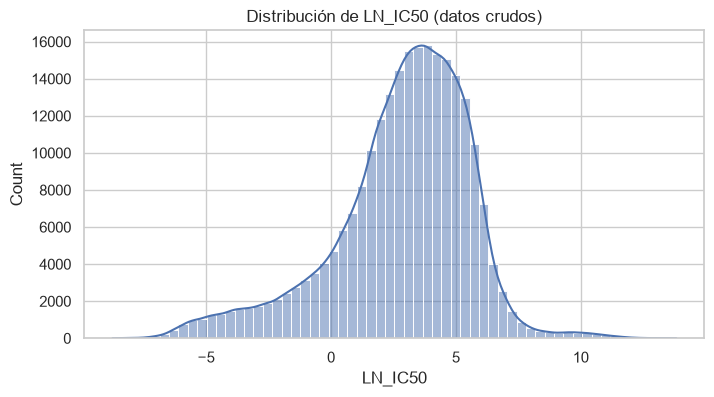

In [5]:
# Visualización 1: distribución de LN_IC50 (histograma)
if 'LN_IC50' in df.columns:
    plt.figure(figsize=(8,4))
    sns.histplot(df['LN_IC50'].dropna(), bins=60, kde=True)
    plt.title('Distribución de LN_IC50 (datos crudos)')
    plt.xlabel('LN_IC50')
    plt.show()

C:\Users\Dell\AppData\Local\Temp\ipykernel_20256\363783481.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['TCGA_DESC'].isin(order)], x='LN_IC50', y='TCGA_DESC', order=order, showfliers=False, palette='Blues')


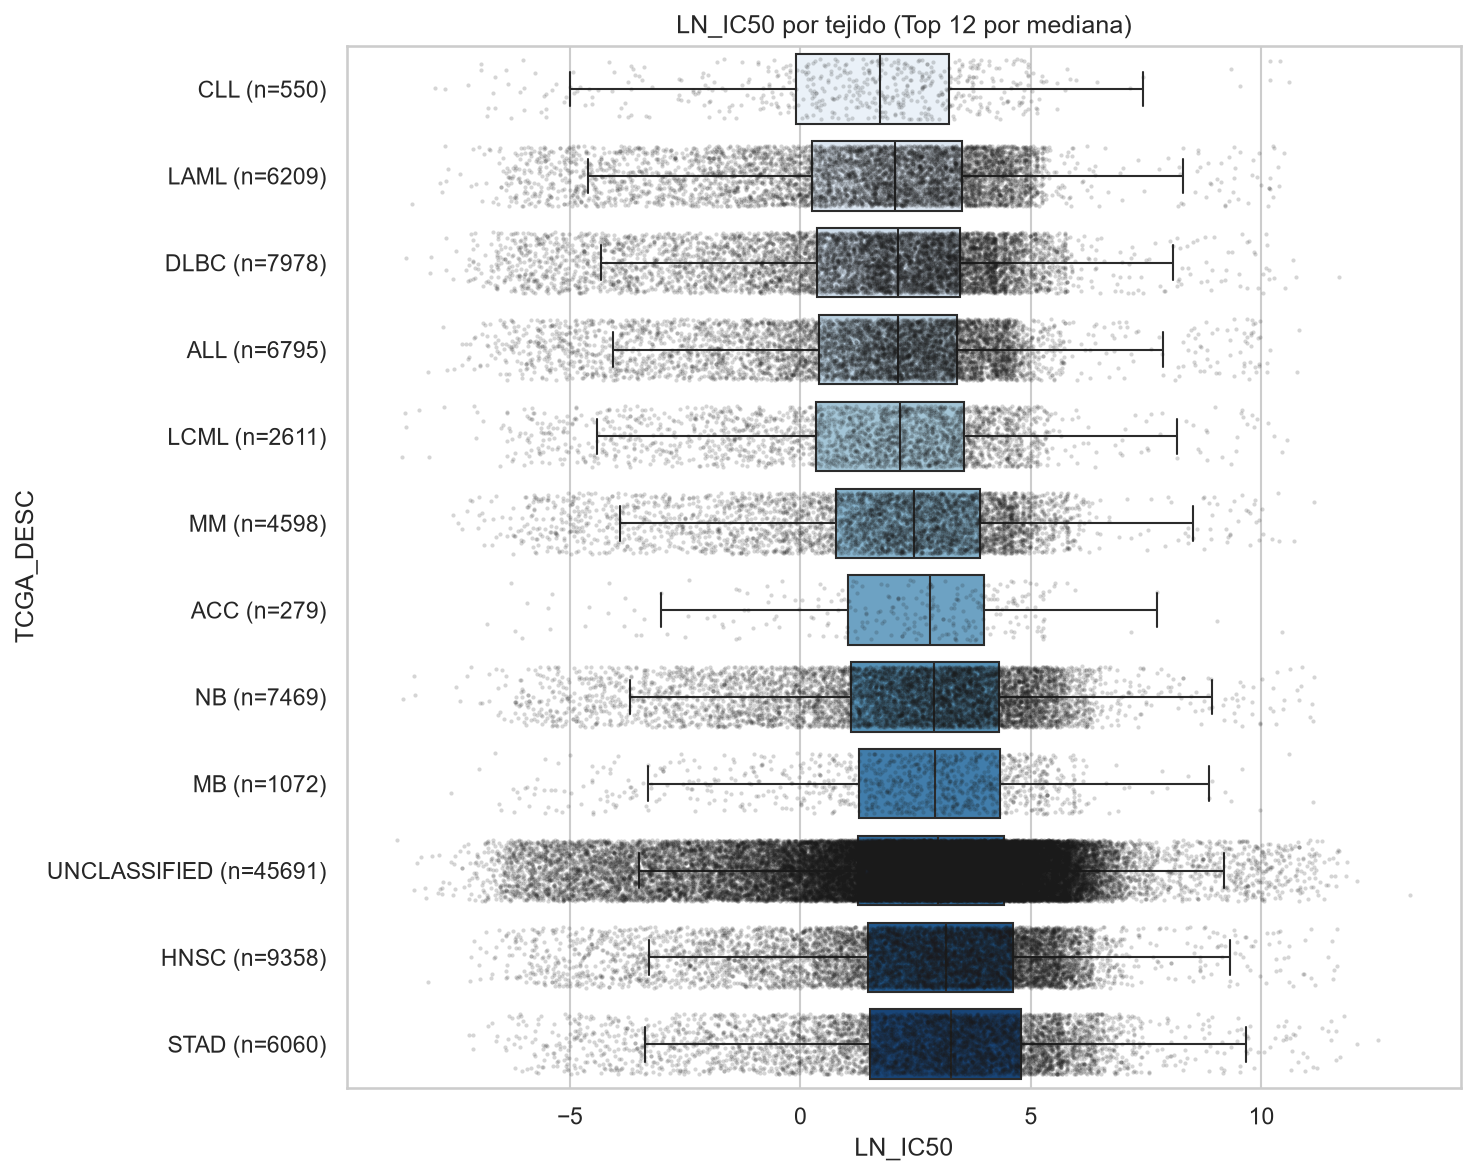

In [6]:
# Visualización 2: boxplot de LN_IC50 por TCGA_DESC (top 12 tejidos)
from pathlib import Path as _Path
if 'TCGA_DESC' in df.columns and 'LN_IC50' in df.columns:
    order = df.groupby('TCGA_DESC')['LN_IC50'].median().dropna().sort_values().head(12).index
    plt.figure(figsize=(10,8), dpi=150)
    sns.boxplot(data=df[df['TCGA_DESC'].isin(order)], x='LN_IC50', y='TCGA_DESC', order=order, showfliers=False, palette='Blues')
    # overlay small jittered points
    sns.stripplot(data=df[df['TCGA_DESC'].isin(order)], x='LN_IC50', y='TCGA_DESC', order=order,
                  size=2, color='k', alpha=0.18, jitter=0.35)
    counts = df['TCGA_DESC'].value_counts().reindex(order)
    ylabels = [f"{lab} (n={counts[lab]})" for lab in order]
    plt.yticks(ticks=range(len(ylabels)), labels=ylabels)
    plt.title('LN_IC50 por tejido (Top 12 por mediana)')
    plt.xlabel('LN_IC50')
    plt.ylabel('TCGA_DESC')
    plt.tight_layout()
    out = _Path().resolve() / 'graficos' / 'ln_ic50_por_tejido.png'
    out.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(out, dpi=200)
    plt.show()

C:\Users\Dell\AppData\Local\Temp\ipykernel_20256\2021261025.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['DRUG_NAME'].isin(order)], x='LN_IC50', y='DRUG_NAME', order=order, showfliers=False, palette='Blues')


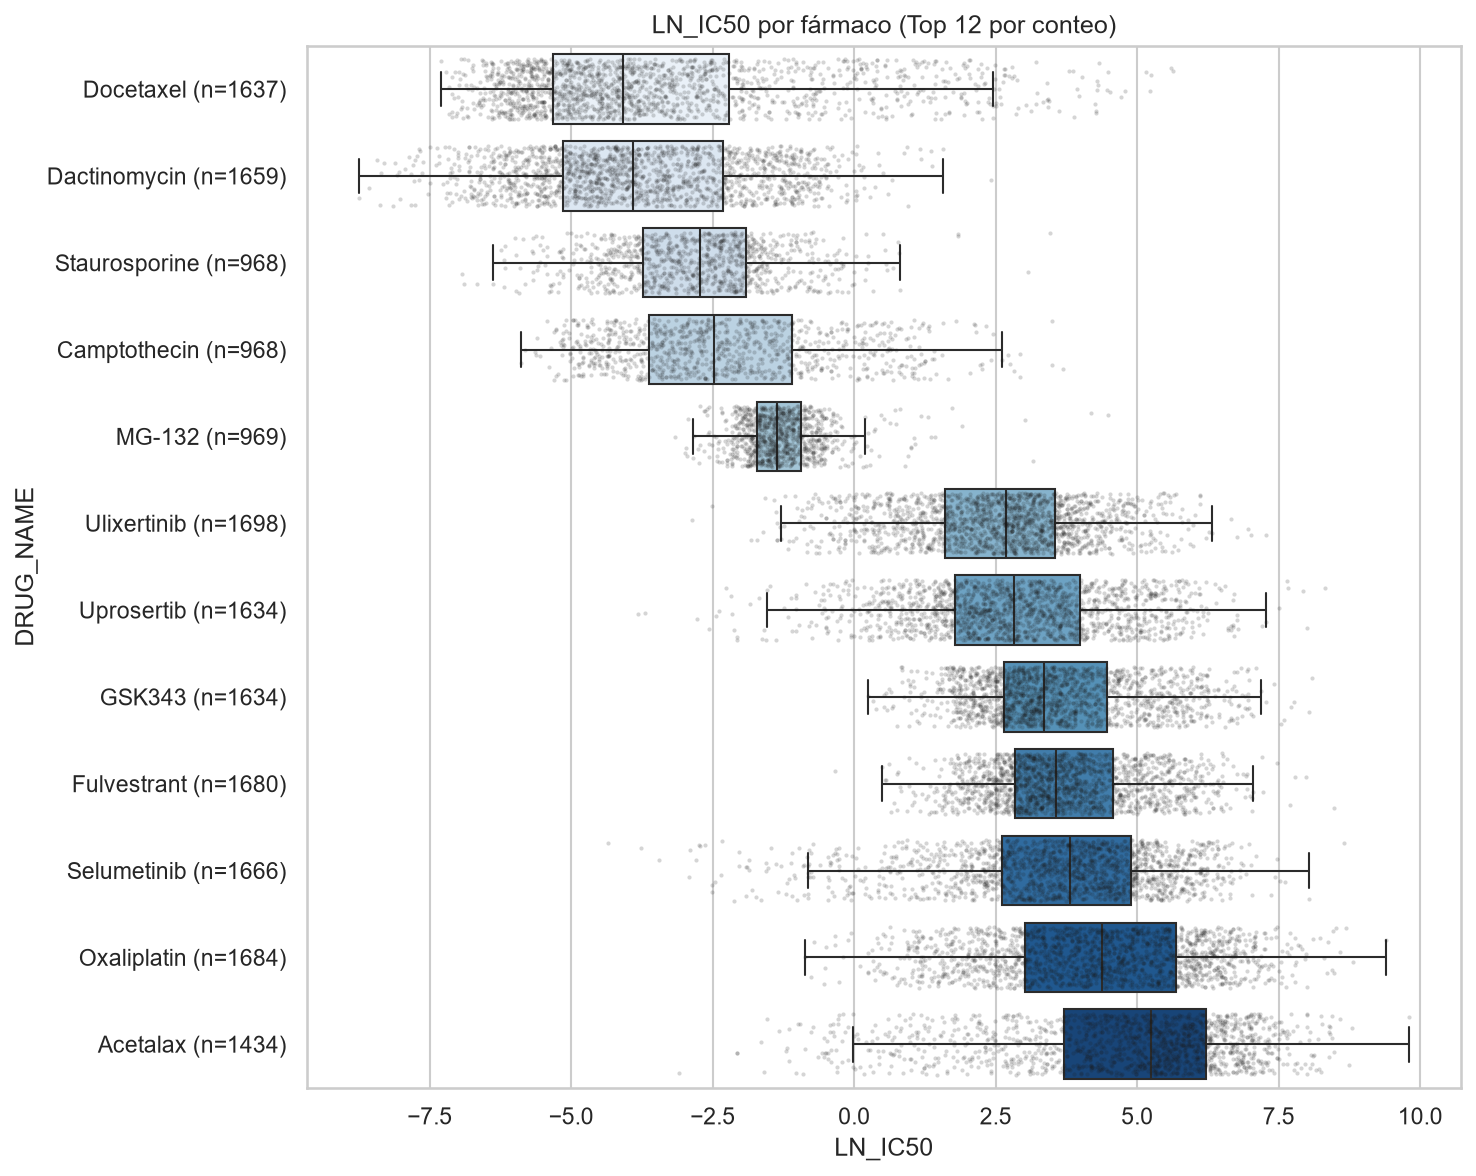

In [7]:
# Visualización 3: LN_IC50 por DRUG_NAME (boxplot) — top 12 fármacos por número de experimentos
from pathlib import Path as _Path
if 'DRUG_NAME' in df.columns and 'LN_IC50' in df.columns:
    top_drugs = df['DRUG_NAME'].value_counts().head(12).index
    # ordenado por media
    order = df[df['DRUG_NAME'].isin(top_drugs)].groupby('DRUG_NAME')['LN_IC50'].median().sort_values().index
    plt.figure(figsize=(10,8), dpi=150)
    sns.boxplot(data=df[df['DRUG_NAME'].isin(order)], x='LN_IC50', y='DRUG_NAME', order=order, showfliers=False, palette='Blues')
    sns.stripplot(data=df[df['DRUG_NAME'].isin(order)], x='LN_IC50', y='DRUG_NAME', order=order,
                  size=2, color='k', alpha=0.18, jitter=0.35)
    counts = df['DRUG_NAME'].value_counts().reindex(order)
    ylabels = [f"{lab} (n={counts[lab]})" for lab in order]
    plt.yticks(ticks=range(len(ylabels)), labels=ylabels)
    plt.title('LN_IC50 por fármaco (Top 12 por conteo)')
    plt.xlabel('LN_IC50')
    plt.ylabel('DRUG_NAME')
    plt.tight_layout()
    out = _Path().resolve() / 'graficos' / 'ln_ic50_por_farmaco.png'
    out.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(out, dpi=200)
    plt.show()

**Conclusiones y insights (Grupo 4)**

- **Insight 1 — Distribución de la respuesta:** `LN_IC50` muestra una distribución amplia y asimétrica, con valores extremos que conviene revisar en el análisis exploratorio.

- **Insight 2 — Diferencias entre tejidos:** Los boxplots por `TCGA_DESC` muestran que algunos tejidos concentran respuestas más sensibles que otros, con dispersión diferente entre grupos.

- **Insight 3 — Diferencias entre fármacos:** Al comparar los principales fármacos, se observan variaciones notorias en la respuesta, lo que sugiere que el efecto depende tanto del tejido como del compuesto.

- **Observación adicional:** Las visualizaciones ayudan a detectar outliers y grupos con comportamiento distinto, lo que sirve como base para análisis posteriores.


